In [1]:
!pip install transformers datasets torch scikit-learn imbalanced-learn -q

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, EarlyStoppingCallback)
from torch.utils.data import Dataset

sns.set_theme(style="whitegrid")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Load ──
df = pd.read_csv("combined_data.csv")
df = df.dropna(subset=["Sentences_clean", "unified_sentiment"]).copy()
df["unified_sentiment"] = pd.to_numeric(df["unified_sentiment"], errors="coerce")
df = df.dropna(subset=["unified_sentiment"])

# ── Label mapping: -1→0 (Neg), 0→1 (Neu), 1→2 (Pos) ──
label_map     = {-1.0: 0, 0.0: 1, 1.0: 2}
id2label      = {0: "Negative", 1: "Neutral", 2: "Positive"}
df["label"]   = df["unified_sentiment"].map(label_map)

print("Class distribution:\n", df["label"].value_counts())
print("\nDomain distribution:\n", df["domain_name"].value_counts())

Class distribution:
 label
2    4940
0     715
1     405
Name: count, dtype: int64

Domain distribution:
 domain_name
Restaurants    2591
Attractions    1500
Products       1483
Movies          486
Name: count, dtype: int64


In [3]:
X = df["Sentences_clean"].astype(str).tolist()
y = df["label"].astype(int).tolist()
domains = df["domain_name"].tolist()

X_train, X_temp, y_train, y_temp, dom_train, dom_temp = train_test_split(
    X, y, domains, test_size=0.2, random_state=SEED, stratify=y)

X_val, X_test, y_val, y_test, dom_val, dom_test = train_test_split(
    X_temp, y_temp, dom_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 4848 | Val: 606 | Test: 606


In [4]:
MODEL_NAME = "UBC-NLP/MARBERTv2"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts):
    return tokenizer(texts, truncation=True, padding=True,
                     max_length=128, return_tensors=None)

train_enc = tokenize(X_train)
val_enc   = tokenize(X_val)
test_enc  = tokenize(X_test)

class ArabicSentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_ds = ArabicSentimentDataset(train_enc, y_train)
val_ds   = ArabicSentimentDataset(val_enc,   y_val)
test_ds  = ArabicSentimentDataset(test_enc,  y_test)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id={v: k for k, v in id2label.items()}
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

training_args = TrainingArguments(
    output_dir              = "./marbert_checkpoints",
    num_train_epochs        = 4,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    eval_strategy           = "epoch",
    save_strategy           = "epoch",
    load_best_model_at_end  = True,
    metric_for_best_model   = "f1_macro",
    greater_is_better       = True,
    warmup_ratio            = 0.1,
    weight_decay             = 0.01,
    logging_dir             = "./marbert_logs",
    logging_steps           = 50,
    seed                    = SEED,
    fp16                    = True,   # free Colab GPU
    report_to               = "none",
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect ide

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.382207,0.372052,0.881188,0.554607,0.851171
2,0.262787,0.384904,0.866337,0.634358,0.864620
3,0.189734,0.476620,0.877888,0.611944,0.862394
4,0.094128,0.549264,0.866337,0.629802,0.864539


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1212, training_loss=0.27255295280969577, metrics={'train_runtime': 28260.4959, 'train_samples_per_second': 0.686, 'train_steps_per_second': 0.043, 'total_flos': 1275573849145344.0, 'train_loss': 0.27255295280969577, 'epoch': 4.0})

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


         MARBERT — Test Set Report
              precision    recall  f1-score   support

    Negative       0.80      0.74      0.77        72
     Neutral       0.22      0.25      0.23        40
    Positive       0.93      0.93      0.93       494

    accuracy                           0.86       606
   macro avg       0.65      0.64      0.64       606
weighted avg       0.87      0.86      0.86       606



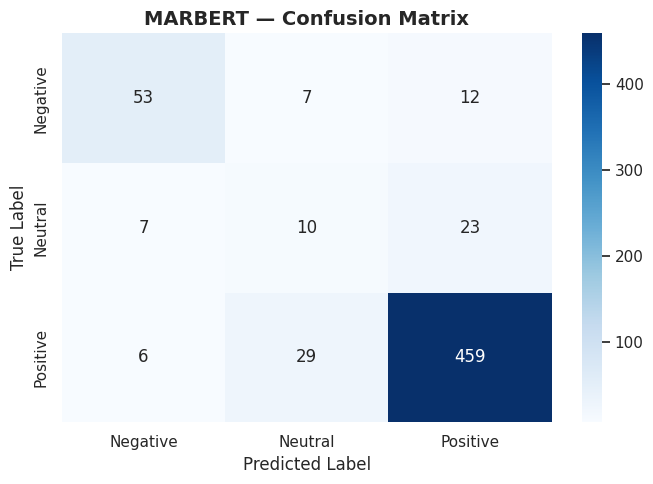

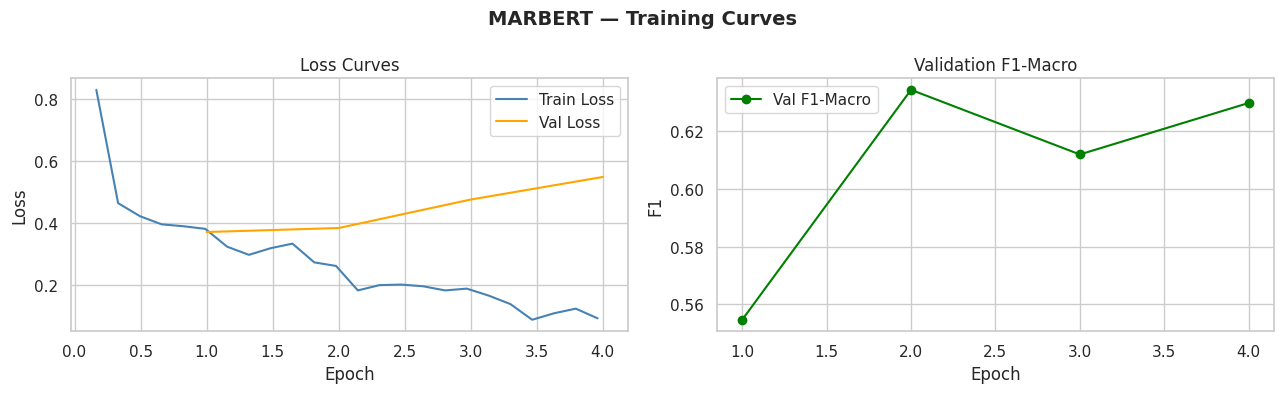

/tmp/ipykernel_16014/141795461.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: f1_score(g["true"], g["pred"], average="macro"))
/tmp/ipykernel_16014/141795461.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=domain_f1, x="domain", y="F1_Macro", palette=palette)


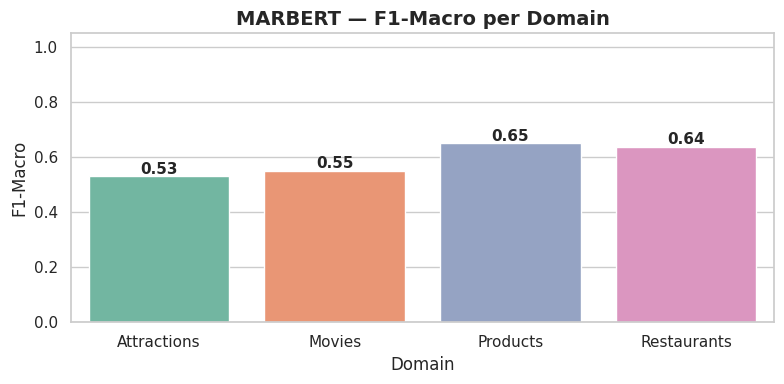

In [7]:
# ── Predictions ──
raw_preds = trainer.predict(test_ds)
y_pred    = np.argmax(raw_preds.predictions, axis=-1)

print("=" * 55)
print("         MARBERT — Test Set Report")
print("=" * 55)
print(classification_report(y_test, y_pred,
      target_names=["Negative", "Neutral", "Positive"]))

# ── 1. Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative","Neutral","Positive"],
            yticklabels=["Negative","Neutral","Positive"])
plt.title("MARBERT — Confusion Matrix", fontsize=14, fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout(); plt.show()

# ── 2. Training Curves (loss + f1) ──
log_history = trainer.state.log_history
train_loss = [(e["epoch"], e["loss"])
              for e in log_history if "loss" in e and "eval_loss" not in e]
eval_data  = [(e["epoch"], e.get("eval_loss"), e.get("eval_f1_macro"))
              for e in log_history if "eval_f1_macro" in e]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(*zip(*train_loss), label="Train Loss", color="steelblue")
axes[0].plot([r[0] for r in eval_data], [r[1] for r in eval_data],
             label="Val Loss", color="orange")
axes[0].set(title="Loss Curves", xlabel="Epoch", ylabel="Loss")
axes[0].legend()

# F1
axes[1].plot([r[0] for r in eval_data], [r[2] for r in eval_data],
             marker="o", color="green", label="Val F1-Macro")
axes[1].set(title="Validation F1-Macro", xlabel="Epoch", ylabel="F1")
axes[1].legend()

plt.suptitle("MARBERT — Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

# ── 3. Per-Domain F1 ──
test_df = pd.DataFrame({"domain": dom_test, "true": y_test, "pred": y_pred})
domain_f1 = (test_df.groupby("domain")
             .apply(lambda g: f1_score(g["true"], g["pred"], average="macro"))
             .reset_index(name="F1_Macro"))

plt.figure(figsize=(8, 4))
palette = sns.color_palette("Set2", len(domain_f1))
bars = sns.barplot(data=domain_f1, x="domain", y="F1_Macro", palette=palette)
for bar, val in zip(bars.patches, domain_f1["F1_Macro"]):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f"{val:.2f}", ha="center", fontsize=11, fontweight="bold")
plt.title("MARBERT — F1-Macro per Domain", fontsize=14, fontweight="bold")
plt.ylim(0, 1.05); plt.xlabel("Domain"); plt.ylabel("F1-Macro")
plt.tight_layout(); plt.show()